**Libraries and Data Loading**

In [25]:
import pandas as pd
import numpy as np
from pathlib import Path

In [26]:
#Data Loading
HOSP = Path(r'hosp')

def read(filename):
    plain = HOSP / filename
    if plain.exists():
        return pd.read_csv(plain, low_memory=False)
    else:
        raise FileNotFoundError

admissions = read('admissions.csv')
patients   = read('patients.csv')
diagnoses  = read('diagnoses_icd.csv')

print('admissions :', admissions.shape)
print('patients   :', patients.shape)
print('diagnoses  :', diagnoses.shape)
admissions.head(3)

admissions : (275, 16)
patients   : (100, 6)
diagnoses  : (4506, 5)


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0


In [27]:
#Label building
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])

admissions = admissions[admissions['admission_type'] != 'NEWBORN'].copy()
admissions = admissions.sort_values(['subject_id', 'admittime']).reset_index(drop = True)

admissions['next_admittime'] = admissions.groupby('subject_id')['admittime'].shift(-1)
admissions['days_to_next'] = (admissions['next_admittime'] - admissions['dischtime']).dt.total_seconds() / 86400

admissions['readmitted_30d'] = (admissions['days_to_next'].between(0,30,inclusive = 'right')).astype(int)

admissions = admissions.dropna(subset=['next_admittime']).copy()

print(admissions['readmitted_30d'].value_counts())
print(f"Readmission rate: {admissions['readmitted_30d'].mean():.1%}")

readmitted_30d
0    123
1     52
Name: count, dtype: int64
Readmission rate: 29.7%


In [28]:
#Feature Engineering
admissions["los_days"] = (admissions['dischtime'] - admissions['admittime']).dt.total_seconds() / 86400

admissions['prior_visit_count'] = admissions.groupby('subject_id').cumcount()

cols_to_merge = [c for c in ['anchor_age', 'gender'] if c not in admissions.columns]
if cols_to_merge:
    admissions = admissions.merge(
        patients[['subject_id'] + cols_to_merge],
        on='subject_id', how='left'
    )


charlson_weights = {'I50': 1, 'J44': 1, 'E11': 1, 'E10': 1, 
                    'N18': 1, 'I21': 1, 'K74': 1, 'K70': 1, 
                    'B20': 6, 'C': 2,}

def icd_to_weight(code):
    if not isinstance(code, str):
        return 0
    for prefix, w in charlson_weights.items():
        if code.startswith(prefix):
            return w
    return 0

diagnoses['charlson_w'] = diagnoses['icd_code'].apply(icd_to_weight)
charlson_per_admit = (diagnoses.groupby('hadm_id')['charlson_w'].sum().reset_index().rename(columns = {'charlson_w': 'charlson_index'}))

admissions = admissions.merge(charlson_per_admit, on = 'hadm_id', how = 'left')
admissions['charlson_index'] = admissions['charlson_index'].fillna(0)

admissions[['los_days','prior_visit_count','anchor_age','charlson_index','readmitted_30d']].head()

,los_days,prior_visit_count,anchor_age,charlson_index,readmitted_30d
0,0.786111,0,52,0,0
1,1.015278,1,52,0,1
2,2.222222,2,52,0,1
3,6.794444,0,55,0,1
4,0.973611,0,80,0,0


In [29]:
keep = [
    'subject_id', 'hadm_id',
    'admission_type', 'insurance', 'gender',
    'anchor_age', 'los_days',
    'prior_visit_count', 'charlson_index',
    'readmitted_30d',
]

keep = [c for c in keep if c in admissions.columns]
cohort = admissions[keep].reset_index(drop = True)

Path('data').mkdir(exist_ok=True)
cohort.to_csv("data/readmission_cohort.csv", index = False)

print(f'Admissions      : {len(cohort):,}')
print(f'Unique patients : {cohort["subject_id"].nunique():,}')
n = cohort["readmitted_30d"].sum()
print(f'Readmitted 30d  : {n} ({n/len(cohort):.1%})')
print(f'Mean LOS        : {cohort["los_days"].mean():.1f} days')
print(f'Mean Charlson   : {cohort["charlson_index"].mean():.2f}')
print('Saved → data/readmission_cohort.csv')
cohort.head()

Admissions      : 175
Unique patients : 48
Readmitted 30d  : 52 (29.7%)
Mean LOS        : 6.8 days
Mean Charlson   : 1.33
Saved → data/readmission_cohort.csv


,subject_id,hadm_id,admission_type,insurance,gender,anchor_age,los_days,prior_visit_count,charlson_index,readmitted_30d
0,10000032,22595853,URGENT,Other,F,52,0.786111,0,0,0
1,10000032,22841357,EW EMER.,Medicaid,F,52,1.015278,1,0,1
2,10000032,29079034,EW EMER.,Medicaid,F,52,2.222222,2,0,1
3,10001217,24597018,EW EMER.,Other,F,55,6.794444,0,0,1
4,10002428,25797028,EU OBSERVATION,Medicare,F,80,0.973611,0,0,0


**Preprocessing and Model Training**

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [31]:
#Preprocessing
num_features = ['anchor_age', 'los_days', 'prior_visit_count', 'charlson_index']
cat_features = ['admission_type', 'insurance', 'gender']

num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ])
cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('encode', OneHotEncoder()), ])

preprocessor = ColumnTransformer([('num', num_pipe, num_features), ('cat', cat_pipe, cat_features), ])

X = cohort[num_features + cat_features]
y = cohort['readmitted_30d']

print('X_shape', X.shape)
print('Class balance:\n', y.value_counts())

X_shape (175, 7)
Class balance:
 readmitted_30d
0    123
1     52
Name: count, dtype: int64


In [32]:
#Training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import KFold, cross_val_score

# Drop rare admission types
counts = X['admission_type'].value_counts()
common = counts[counts >= 5].index
X_clean = X[X['admission_type'].isin(common)].reset_index(drop=True)
y_clean = y[X['admission_type'].isin(common)].reset_index(drop=True)

print(f'Rows: {len(X_clean)}')

cv = KFold(n_splits=3, shuffle=True, random_state=42)

for name, clf in [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, random_state=42)),
]:
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_clean, y_clean, cv=cv, scoring='roc_auc')
    print(f'{name:25s}  AUC: {scores.mean():.3f} +- {scores.std():.3f}')

Rows: 175
Logistic Regression        AUC: 0.525 +- 0.086
Gradient Boosting          AUC: 0.570 +- 0.106


In [33]:
#TrainTest Split
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size= 0.2, random_state= 60)

#Gradient Boosting
base_pipe = Pipeline([('pre', preprocessor), ('clf', GradientBoostingClassifier(n_estimators=100, random_state=60))])
calibrated = CalibratedClassifierCV(base_pipe, method = 'isotonic', cv = 3)
calibrated.fit(X_train, y_train)

probs = calibrated.predict_proba(X_test)[:, 1]

print(f'Test AUC      : {roc_auc_score(y_test, probs):.3f}')
print(f'Brier Score   : {brier_score_loss(y_test, probs):.3f}')
print(f'Test patients : {len(y_test)}')
print(f'Positive rate : {y_test.mean():.1%}')

Test AUC      : 0.764
Brier Score   : 0.175
Test patients : 35
Positive rate : 22.9%


In [34]:
#Feature Importances
import subprocess
subprocess.run(['pip', 'install', 'shap', '--quiet'], check = True)
import shap
import matplotlib.pyplot

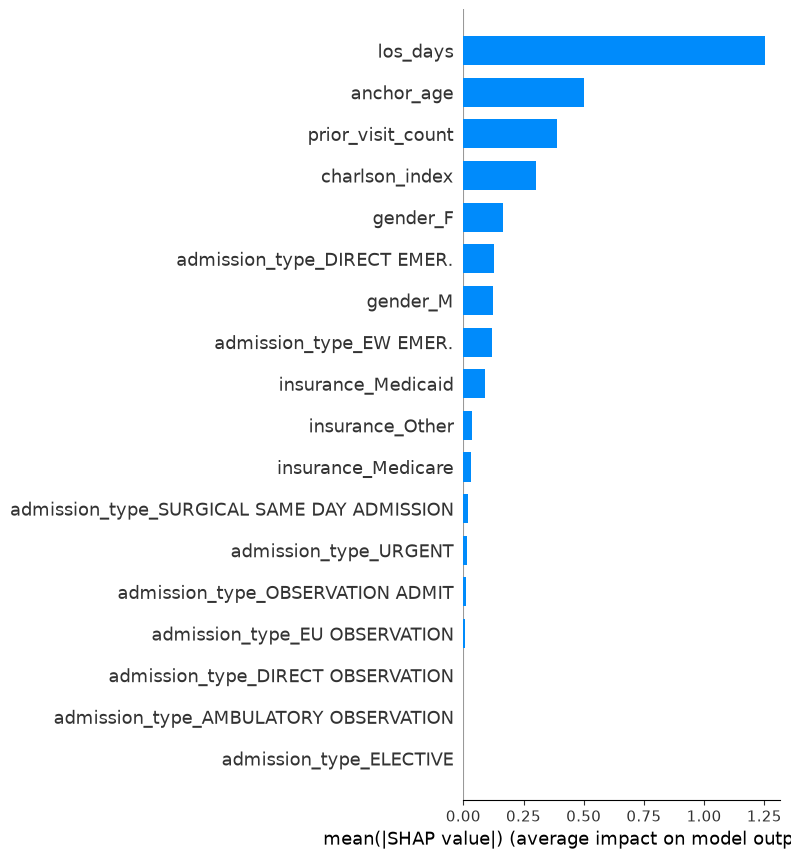

In [35]:
#extracting gradient boosting model
gb_model =  calibrated.calibrated_classifiers_[0].estimator.named_steps['clf']
pre = calibrated.calibrated_classifiers_[0].estimator.named_steps['pre']

X_test_transformed = pre.transform(X_test)

explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_transformed)

#Feature names after One-Hot Encoding
cat_names = list(pre.named_transformers_['cat'].named_steps['encode'].get_feature_names_out(cat_features))
features_names = num_features + cat_names

shap.summary_plot(shap_values, X_test_transformed, features_names, plot_type= 'bar')

**Pytorch**

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

FEATURES = ['los_days', 'anchor_age', 'prior_visit_count', 'charlson_index']

X_num = X_clean[FEATURES].values.astype('float32')
y_arr = y_clean.values.astype('float32')

#Impute and Scale
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_num = imputer.fit_transform(X_num).astype('float32')
y_num = imputer.fit_transform(X_num).astype('float32')

#Train Test Splitting
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_num, y_arr, test_size=0.2, random_state=60)
print(f'Train: {X_tr.shape}  Test: {X_te.shape}')
print(f'Positive rate train: {y_tr.mean():.1%}  test: {y_te.mean():.1%}')


Train: (140, 4)  Test: (35, 4)
Positive rate train: 31.4%  test: 22.9%


**Model Training**

In [37]:
class ReadmissionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        return torch.sigmoid(self.fc3(x)).squeeze()


class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# Weighted sampler for class imbalance
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
weights    = torch.where(torch.tensor(y_tr) == 1,
                         torch.tensor(pos_weight),
                         torch.tensor(1.0))
sampler    = WeightedRandomSampler(weights, len(weights))

train_ds = TabularDataset(X_tr, y_tr)
test_ds  = TabularDataset(X_te, y_te)
train_dl = DataLoader(train_ds, batch_size=16, sampler=sampler)
test_dl  = DataLoader(test_ds,  batch_size=16)

model     = ReadmissionNet(input_dim=X_tr.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

for epoch in range(100):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}  loss: {loss.item():.4f}')

print('Training complete.')

Epoch  20  loss: 0.6941
Epoch  40  loss: 0.7214
Epoch  60  loss: 0.7469
Epoch  80  loss: 0.7682
Epoch 100  loss: 0.7100
Training complete.


**MC Dropout inference and Uncertainty Quantification**

In [38]:
from sklearn.metrics import roc_auc_score

X_te_t = torch.tensor(X_te)

T = 30
model.train()  # keeps dropout active
with torch.no_grad():
    preds = torch.stack([model(X_te_t) for _ in range(T)])

mean_pred = preds.mean(0).numpy()
std_pred  = preds.std(0).numpy()

auc = roc_auc_score(y_te, mean_pred)
print(f'PyTorch AUC       : {auc:.3f}')
print(f'Sklearn baseline  : 0.764')
print(f'Improvement       : {auc - 0.764:+.3f}')
print()

uncertain = std_pred > 0.12
print(f'High uncertainty  : {uncertain.sum()} / {len(uncertain)} patients flagged')
for i, (p, s, u) in enumerate(zip(mean_pred, std_pred, uncertain)):
    flag = ' ⚠ defer' if u else ''
    print(f'  Patient {i+1:2d}: risk={p:.2f}  uncertainty={s:.3f}{flag}')

PyTorch AUC       : 0.532
Sklearn baseline  : 0.764
Improvement       : -0.232

High uncertainty  : 0 / 35 patients flagged
  Patient  1: risk=0.49  uncertainty=0.018
  Patient  2: risk=0.49  uncertainty=0.026
  Patient  3: risk=0.50  uncertainty=0.040
  Patient  4: risk=0.49  uncertainty=0.030
  Patient  5: risk=0.50  uncertainty=0.028
  Patient  6: risk=0.49  uncertainty=0.021
  Patient  7: risk=0.50  uncertainty=0.053
  Patient  8: risk=0.49  uncertainty=0.040
  Patient  9: risk=0.51  uncertainty=0.047
  Patient 10: risk=0.51  uncertainty=0.057
  Patient 11: risk=0.49  uncertainty=0.023
  Patient 12: risk=0.48  uncertainty=0.017
  Patient 13: risk=0.49  uncertainty=0.026
  Patient 14: risk=0.48  uncertainty=0.020
  Patient 15: risk=0.51  uncertainty=0.035
  Patient 16: risk=0.48  uncertainty=0.039
  Patient 17: risk=0.51  uncertainty=0.066
  Patient 18: risk=0.50  uncertainty=0.044
  Patient 19: risk=0.48  uncertainty=0.031
  Patient 20: risk=0.49  uncertainty=0.039
  Patient 21: ri

**Comparing the Sklearn and PyTorch implementation, it looks like the Pytorch architecture underperforms**<br>
This is due to the dataset being trained is not large enough for a Neural Network to accurately train on